In [2]:
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.colors as mcolors
import colorsys
from typing import Dict, List

import pickle
import os
BASE_DIR = "/capstor/store/cscs/swissai/infra01/apertus_probes"


In [8]:
def load_pkl(path): 
    with open(path, "rb") as f:
        return pickle.load(f)

def get_paths_for_dataset(dataset_name: str, variant: str = "leave") -> Dict[str, str]:
    """
    Get paths to probe dataframes for both models.

    Args:
        dataset_name: Name of the dataset (e.g., "mmlu_high_school", "ARC-Challenge")
        variant: Either "leave" or "transform"

    Returns:
        dict: Mapping from model name to pickle file path
    """
    filename = f"df_probes_{variant}.pkl"
    paths = {
        "Apertus-8B-Instruct-2509": os.path.join(
            BASE_DIR, dataset_name, "Apertus-8B-Instruct-2509", filename
        ),
        "Llama-3.1-8B-Instruct": os.path.join(
            BASE_DIR, dataset_name, "Llama-3.1-8B-Instruct", filename
        ),
    }

    # Validate paths exist
    for model, path in paths.items():
        if not os.path.exists(path):
            print(f"⚠️ Warning: Path does not exist: {path}")
    
    return paths

In [ ]:
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import colorsys

def _adjust_lightness(color, factor=1.0):
    """factor > 1 -> lighter, < 1 -> darker."""
    rgb = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    l = max(0, min(1, l * factor))
    return colorsys.hls_to_rgb(h, l, s)

def plot_rmse_comparison_multi(
    results_by_llm: dict,
    models_to_plot,
    token_positions,
    title_suffix: str = ""
):
    plt.figure(figsize=(14, 6))

    # Base colors per LLM
    llm_base_color = {
        "Apertus-8B-Instruct-2509": "tab:orange",
        "Llama-3.1-8B-Instruct": "tab:blue",
    }
    llm_label = {
        "Apertus-8B-Instruct-2509": "Apertus",
        "Llama-3.1-8B-Instruct": "Llama",
    }

    # Lightness factor per probe model
    probe_lightness = {
        "L-0.1": 0.9,   # slightly darker
        "L-0.25": 1.2,  # slightly lighter
    }

    # ---------- PLOT LINES ----------
    for llm_name, df in results_by_llm.items():
        base = llm_base_color.get(llm_name, "black")

        for model in models_to_plot:
            light_factor = probe_lightness.get(model, 1.0)
            color = _adjust_lightness(base, light_factor)

            for token_pos in token_positions:
                mask = (df["Model"] == model) & (df["Token-Pos"] == token_pos)
                group = df[mask]
                if group.empty:
                    continue

                layer_averages = group.groupby("Layer")[["RMSE", "Dummy-RMSE"]].mean()

                # RMSE: solid
                plt.plot(
                    layer_averages.index,
                    layer_averages["RMSE"],
                    color=color,
                    linestyle="-",
                    linewidth=2.0,
                    alpha=1.0,
                )
                # Dummy-RMSE: dashed
                plt.plot(
                    layer_averages.index,
                    layer_averages["Dummy-RMSE"],
                    color=color,
                    linestyle="--",
                    linewidth=1.5,
                    alpha=0.9,
                )

    ax = plt.gca()

    # ---------- SINGLE LEGEND ----------
    legend_handles = []
    legend_labels = []

    # One solid line per (LLM, probe model) combo
    for llm_name in results_by_llm.keys():
        base = llm_base_color.get(llm_name, "black")
        for model in models_to_plot:
            light_factor = probe_lightness.get(model, 1.0)
            color = _adjust_lightness(base, light_factor)
            legend_handles.append(
                Line2D([0], [0], color=color, linestyle="-", linewidth=2.0)
            )
            legend_labels.append(f"{llm_label[llm_name]} {model}")

    # One dashed line entry explaining the dummy
    legend_handles.append(
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.8)
    )
    legend_labels.append("Dummy RMSE")

    ax.legend(
        legend_handles,
        legend_labels,
        fontsize=10,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        title=None,       # or "Lines" if you want a title
        frameon=True,
    )

    # ---------- STYLING ----------
    plt.title(title_suffix, fontsize=16, pad=14)
    plt.xlabel("Layer", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


In [10]:
DATASET_NAMES = ["mmlu_high_school", "mmlu_professional", "ARC-Challenge", "ARC-Easy", "sms_spam"]
DATASET_TITLES = ["MMLU High School", "MMLU Professional", "ARC Challenge", "ARC Easy", "SMS Spam"]
MODEL_NAMES = ["Apertus-8B-Instruct-2509", "Llama-3.1-8B-Instruct"]
INDEX = 0

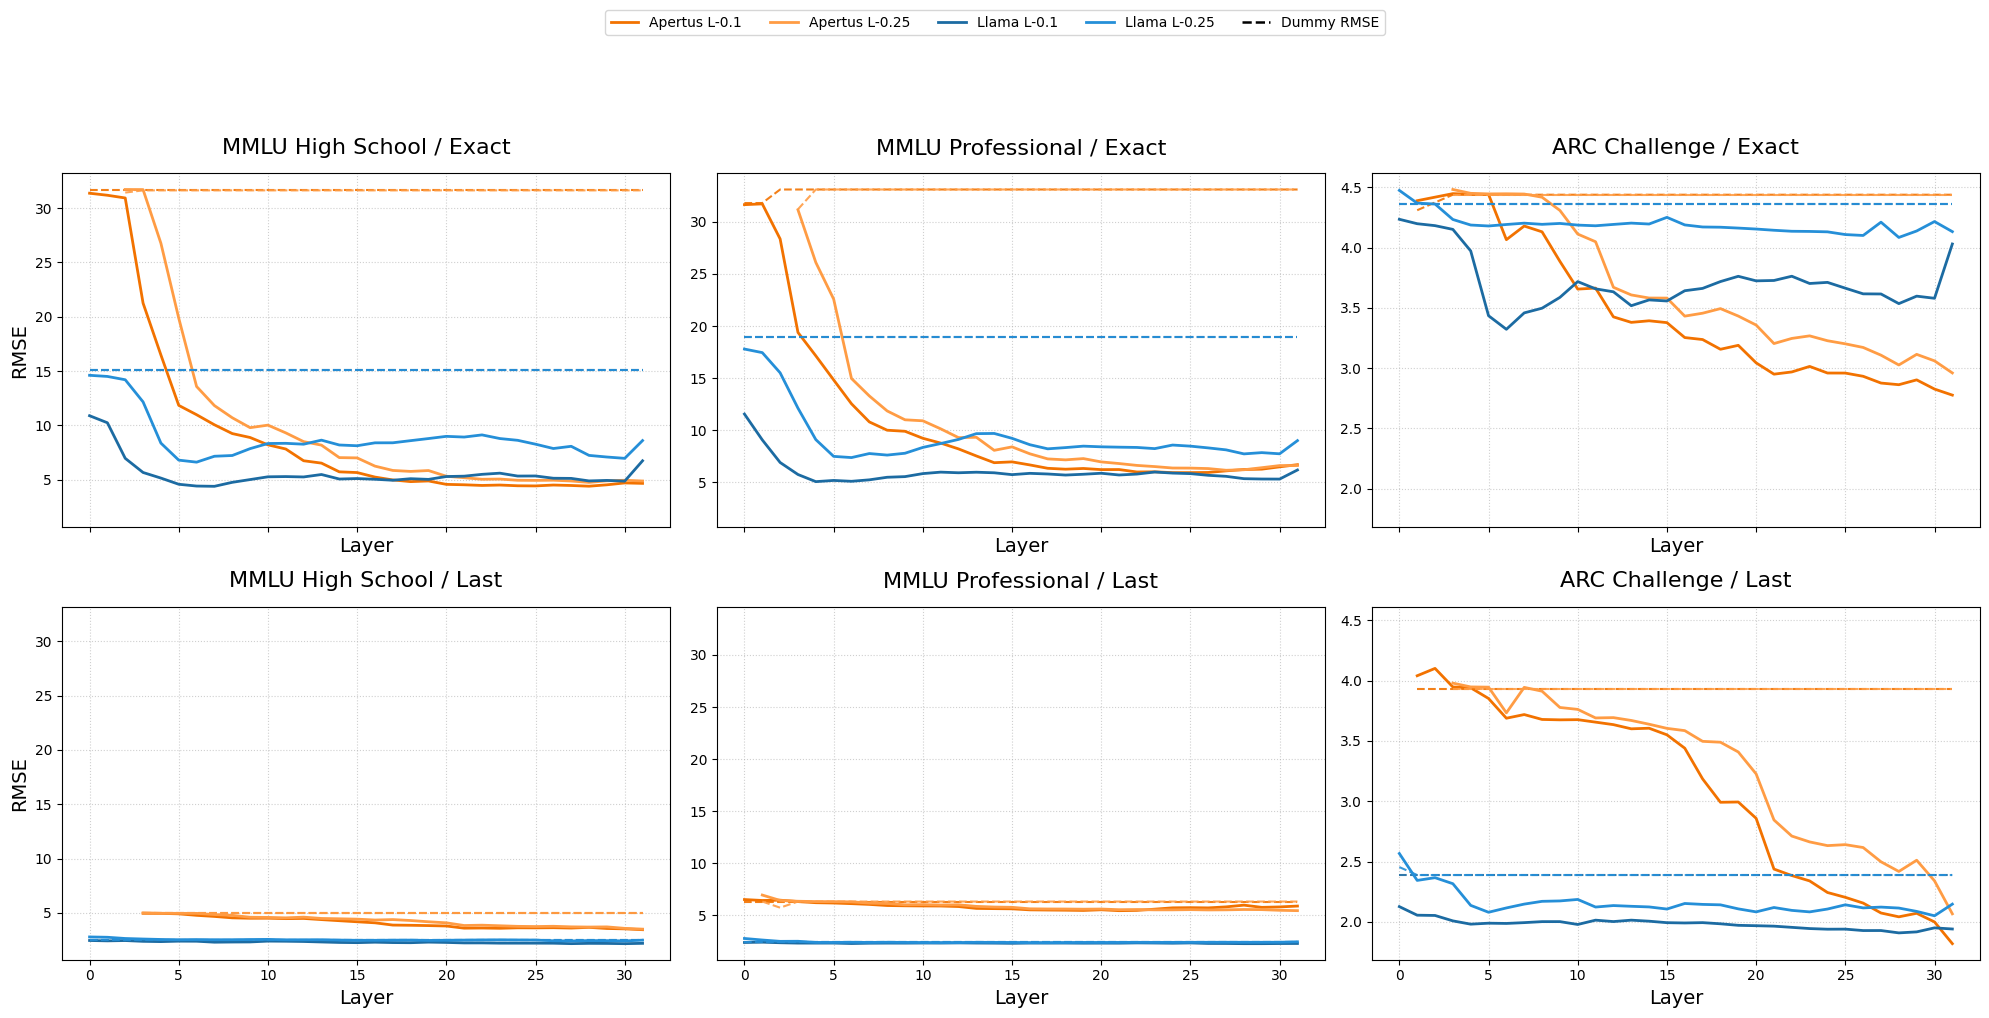

In [ ]:
INDICES = [0, 1, 2]                     # which datasets to use
variant = "transform"
models_to_plot = ["L-0.1", "L-0.25"]

# 2 rows (Exact / Last) × N datasets
fig, axes = plt.subplots(
    2, len(INDICES),
    figsize=(20, 10),
    sharex="col",   # share x within each column
)

legend_handles, legend_labels = None, None

for col, idx in enumerate(INDICES):
    dataset_name = DATASET_NAMES[idx]
    dataset_title = DATASET_TITLES[idx]

    paths = get_paths_for_dataset(dataset_name, variant=variant)
    results_by_llm = {model: load_pkl(p) for model, p in paths.items()}

    # ---- Row 0: Exact token ----
    handles, labels = plot_rmse_on_axis(
        axes[0, col],
        results_by_llm=results_by_llm,
        models_to_plot=models_to_plot,
        token_positions=["exact"],
        title_suffix=f"{dataset_title} / Exact",
        add_legend=False,
    )

    # ---- Row 1: Last token ----
    plot_rmse_on_axis(
        axes[1, col],
        results_by_llm=results_by_llm,
        models_to_plot=models_to_plot,
        token_positions=["last"],
        title_suffix=f"{dataset_title} / Last",
        add_legend=False,
    )

    # grab legend info from first subplot only
    if legend_handles is None:
        legend_handles, legend_labels = handles, labels

# Only left column gets y-labels (optional, for cleanliness)
for row in range(2):
    for col in range(1, len(INDICES)):
        axes[row, col].set_ylabel("")

# One shared legend at the top
fig.legend(
    legend_handles,
    legend_labels,
    fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(legend_labels),
    frameon=True,
)

fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


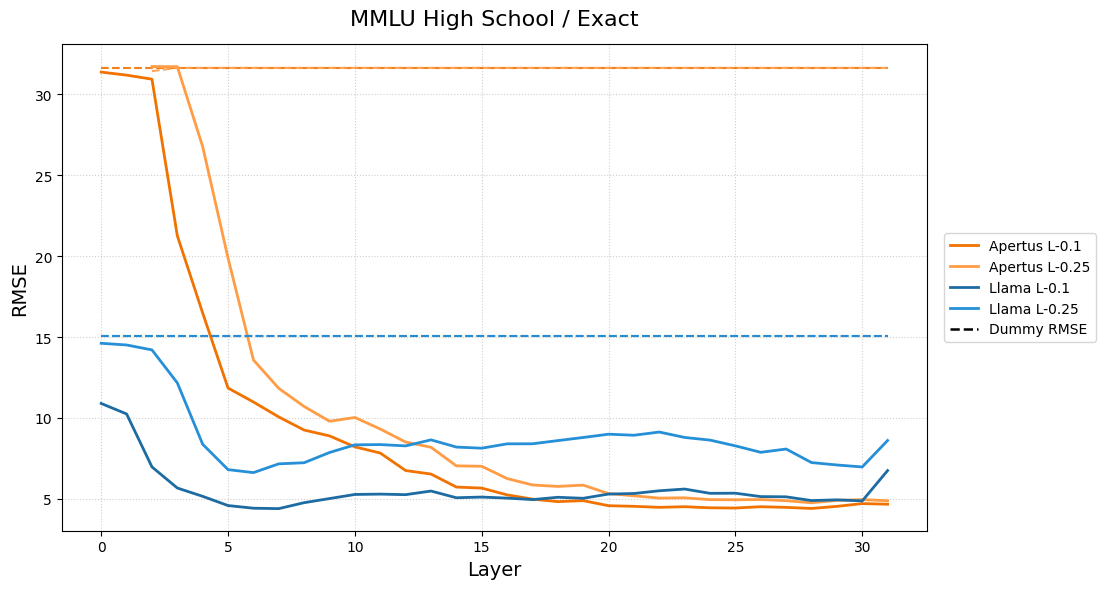

In [11]:

dataset_name = DATASET_NAMES[INDEX]
dataset_in_title = DATASET_TITLES[INDEX]
variant = "transform"                   # or "transform"
paths = get_paths_for_dataset(dataset_name, variant=variant)
results_by_llm = {model: load_pkl(p) for model, p in paths.items()}

models_to_plot = ["L-0.1", "L-0.25"]
# exact position
plot_rmse_comparison_multi(
    results_by_llm,
    models_to_plot=models_to_plot,
    token_positions=["exact"],
    title_suffix=f"{dataset_in_title} / Exact",
)


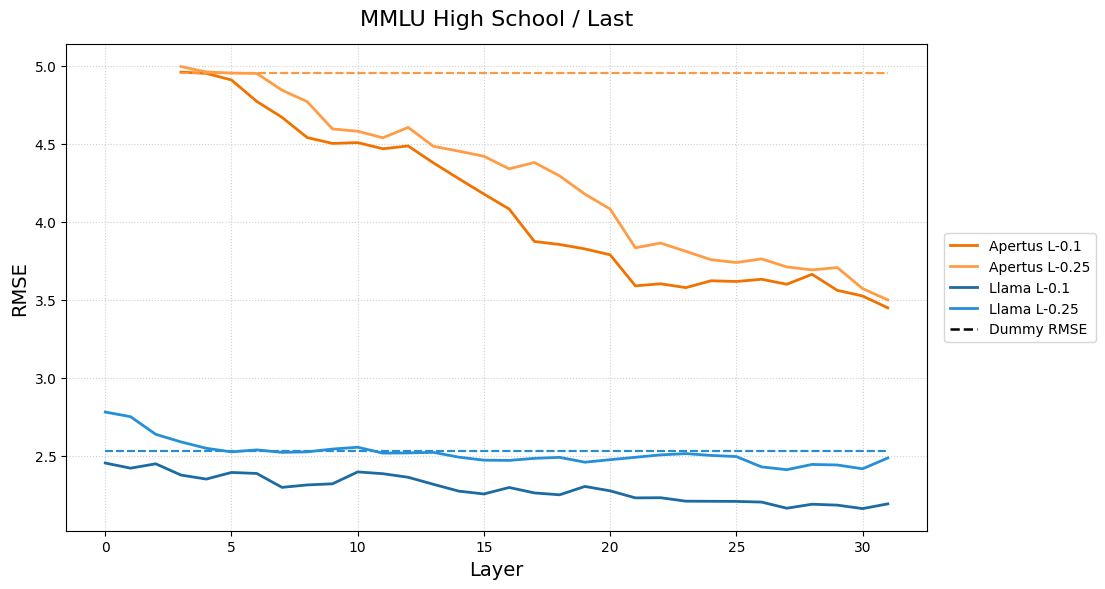

In [64]:
# last token
plot_rmse_comparison_multi(
    results_by_llm,
    models_to_plot=models_to_plot,
    token_positions=["last"],
    title_suffix=f"{dataset_in_title} / Last",
)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



# Root where you rsynced steering outputs
ROOT = Path("/capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs")

MODEL_DIR = "Apertus-8B-Instruct-2509"

# mapping: pretty label -> folder name
DATASETS = {
    "MMLU-HS":   ("mmlu_high_school", "mmlu_hs_experiment"),
    "MMLU-PROF": ("mmlu_professional", "mmlu_pro_experiment"),
    "ARC-EASY": ("ARC-Easy", "mmlu_arc_easy_experiment"),
    "ARC-CHALLENGE": ("ARC-Challenge", "mmlu_arc_challenge_experiment"),
    "SMS-SPAM": ("sms_spam", "sms_spam")
}

# this must match the prefix you used in --fname
EXP_PREFIX = "mmlu_hs_experiment"       # or a more generic "mera_experiment"
N_TEST = 250                            # nr_test_samples you used

# full steering_key substring for the method you care about
METHOD_SUBSTR = "optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both"
CALIB_TARGET = "exact"                  # 'exact' vs 'last'

rows = []

for pretty_name, ds_folder in DATASETS.items():
    csv_path = (
        ROOT / ds_folder[0] / MODEL_DIR / "steering" /
        f"{ds_folder[1]}_{N_TEST}_steering_all_results.csv"
    )
    print("Reading", csv_path)

    df = pd.read_csv(csv_path)
    print(df.columns.tolist())

    # Inspect once if you're unsure:
    # print(df["steering_key"].unique())

    # Pick the row for the steered method calibrated for "exact"
    row = df[
        df["steering_key"].str.contains(METHOD_SUBSTR)
        & df["alpha_calibration_token_pos_target"].fillna("").eq(CALIB_TARGET)
    ].iloc[0]

    rows.append({
        "Dataset": pretty_name,
        "SPI Exact": row["SPI Exact"],             # already baseline-relative
        "Delta Accuracy Exact": row["Delta Accuracy Exact"],
    })

res = pd.DataFrame(rows)
print(res)

Reading /capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs/mmlu_high_school/Apertus-8B-Instruct-2509/steering/mmlu_hs_experiment_250_steering_all_results.csv
['Unnamed: 0', 'steering_key', 'dataset_name', 'alpha_calibration_token_pos_target', 'best_alpha_single', 'no_steering', 'logging_calibration_table_key', 'logging_theta_table_key', 'Error Last', 'Accuracy Last', 'Error Last Std', 'Accuracy Last Std', 'Error Last Min', 'Error Last Max', 'Error Last Median', 'Error Last 25th Percentile', 'Error Last 75th Percentile', 'Error Last 90th Percentile', 'Error Last 95th Percentile', 'Correct Predictions Last', 'Error Exact', 'Accuracy Exact', 'Error Exact Std', 'Accuracy Exact Std', 'Error Exact Min', 'Error Exact Max', 'Error Exact Median', 'Error Exact 25th Percentile', 'Error Exact 75th Percentile', 'Error Exact 90th Percentile', 'Error Exact 95th Percentile', 'Correct Predictions Exact', 'F1 Score Last', 'Recall Last', 'Precision Last', 'F1 Score Exact', 'Recall Exact'

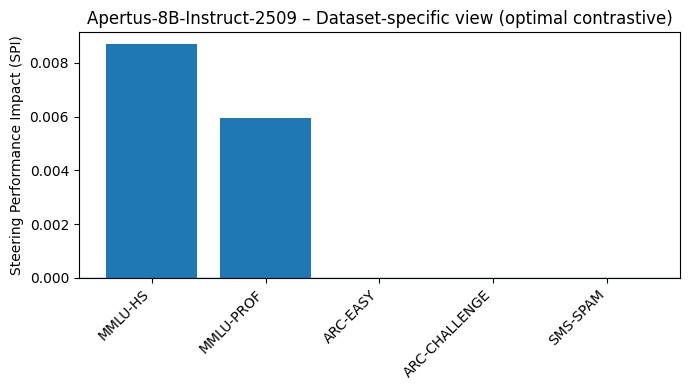

In [6]:
# --- Single-metric bar plot (SPI Exact) ---
fig, ax = plt.subplots(figsize=(7, 4))

# zero line = no steering effect
ax.axhline(0, linewidth=1)

ax.bar(res["Dataset"], res["SPI Exact"])

ax.set_ylabel("Steering Performance Impact (SPI)")
ax.set_title("Apertus-8B-Instruct-2509 – Dataset-specific view (optimal contrastive)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

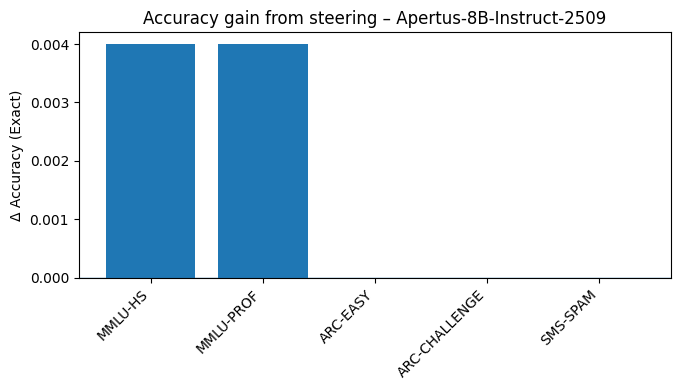

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, linewidth=1)
ax.bar(res["Dataset"], res["Delta Accuracy Exact"])
ax.set_ylabel("Δ Accuracy (Exact)")
ax.set_title("Accuracy gain from steering – Apertus-8B-Instruct-2509")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Reading /capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs/mmlu_high_school/Apertus-8B-Instruct-2509/steering/mmlu_hs_experiment_250_steering_all_results.csv
Reading /capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs/mmlu_professional/Apertus-8B-Instruct-2509/steering/mmlu_pro_experiment_250_steering_all_results.csv
Reading /capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs/ARC-Easy/Apertus-8B-Instruct-2509/steering/mmlu_arc_easy_experiment_250_steering_all_results.csv
Reading /capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs/ARC-Challenge/Apertus-8B-Instruct-2509/steering/mmlu_arc_challenge_experiment_250_steering_all_results.csv
Reading /capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs/sms_spam/Apertus-8B-Instruct-2509/steering/sms_spam_250_steering_all_results.csv
          Dataset                   Method  SPI Exact  Delta Accuracy Exact  \
0         MMLU-HS     Baseline (prompting)        NaN   

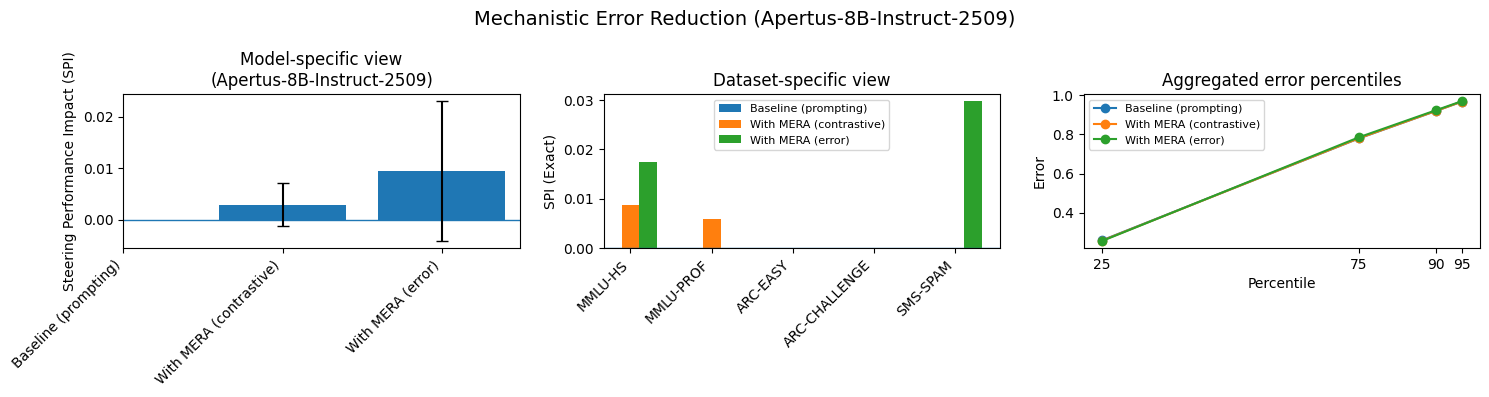

In [11]:
ROOT = Path("/capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs")
MODEL_DIR = "Apertus-8B-Instruct-2509"

# pretty label -> (folder_name, fname_prefix)
DATASETS = {
    "MMLU-HS"      : ("mmlu_high_school",   "mmlu_hs_experiment"),
    "MMLU-PROF"    : ("mmlu_professional",  "mmlu_pro_experiment"),
    "ARC-EASY"     : ("ARC-Easy",           "mmlu_arc_easy_experiment"),
    "ARC-CHALLENGE": ("ARC-Challenge",      "mmlu_arc_challenge_experiment"),
    "SMS-SPAM"     : ("sms_spam",           "sms_spam"),
}

N_TEST = 250            # nr_test_samples used in steering_run.py
CALIB_TARGET = "exact"  # we want rows calibrated for "exact"

# human label -> substring to match in `steering_key`
METHODS = {
    "Baseline (prompting)"      : "no_steering",
    "With MERA (contrastive)"   : "optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both",
    "With MERA (error)"         : "optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both",
}

def pick_row(df: pd.DataFrame, key_substr: str, calib: str | None):
    """Return the row for a given method (by substring) and calibration target."""
    if key_substr == "no_steering":
        mask = df["steering_key"].eq("no_steering")
    else:
        mask = df["steering_key"].str.contains(key_substr)
        if calib is not None:
            mask &= df["alpha_calibration_token_pos_target"].fillna("").eq(calib)
    sel = df[mask]
    if sel.empty:
        raise ValueError(f"No row found for key_substr={key_substr}, calib={calib}")
    return sel.iloc[0]

rows = []

for pretty_name, (folder, prefix) in DATASETS.items():
    csv_path = ROOT / folder / MODEL_DIR / "steering" / f"{prefix}_{N_TEST}_steering_all_results.csv"
    print("Reading", csv_path)
    df = pd.read_csv(csv_path)

    for method_label, substr in METHODS.items():
        row = pick_row(df, substr, CALIB_TARGET if substr != "no_steering" else None)

        rows.append({
            "Dataset" : pretty_name,
            "Method"  : method_label,
            # main metrics we care about
            "SPI Exact"             : row["SPI Exact"],
            "Delta Accuracy Exact"  : row["Delta Accuracy Exact"],
            # percentile metrics for the right-hand panel
            "Error P25" : row["Error Exact 25th Percentile"],
            "Error P75" : row["Error Exact 75th Percentile"],
            "Error P90" : row["Error Exact 90th Percentile"],
            "Error P95" : row["Error Exact 95th Percentile"],
        })

res = pd.DataFrame(rows)
print(res)

methods_order = list(METHODS.keys())
datasets_order = list(DATASETS.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

# ---------- (a) Model-specific view: SPI averaged across datasets ----------
ax0 = axes[0]

grouped = (
    res.groupby("Method")["SPI Exact"]
       .agg(["mean", "std"])
       .reindex(methods_order)
)
x0 = np.arange(len(methods_order))

ax0.axhline(0, linewidth=1)
ax0.bar(x0, grouped["mean"], yerr=grouped["std"], capsize=4)

ax0.set_xticks(x0)
ax0.set_xticklabels(methods_order, rotation=45, ha="right")
ax0.set_ylabel("Steering Performance Impact (SPI)")
ax0.set_title("Model-specific view\n(Apertus-8B-Instruct-2509)")

# ---------- (b) Dataset-specific view: SPI per dataset & method ----------
ax1 = axes[1]

x = np.arange(len(datasets_order))
width = 0.22  # bar width
offsets = np.linspace(-width, width, len(methods_order))

for i, method in enumerate(methods_order):
    sub = res[res["Method"] == method].set_index("Dataset").reindex(datasets_order)
    ax1.bar(x + offsets[i], sub["SPI Exact"], width=width, label=method)

ax1.axhline(0, linewidth=1)
ax1.set_xticks(x)
ax1.set_xticklabels(datasets_order, rotation=45, ha="right")
ax1.set_ylabel("SPI (Exact)")
ax1.set_title("Dataset-specific view")
ax1.legend(fontsize=8)

# ---------- (c) Aggregated error percentiles ----------
ax2 = axes[2]

percentiles = [25, 75, 90, 95]
for method in methods_order:
    sub = res[res["Method"] == method]
    y = [
        sub["Error P25"].mean(),
        sub["Error P75"].mean(),
        sub["Error P90"].mean(),
        sub["Error P95"].mean(),
    ]
    ax2.plot(percentiles, y, marker="o", label=method)

ax2.set_xlabel("Percentile")
ax2.set_ylabel("Error")
ax2.set_title("Aggregated error percentiles")
ax2.set_xticks(percentiles)
ax2.legend(fontsize=8)

fig.suptitle("Mechanistic Error Reduction (Apertus-8B-Instruct-2509)", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
import pandas as pd

ROOT = Path("/capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs")
ds = "mmlu_high_school"
model = "Apertus-8B-Instruct-2509"

steering_dir = ROOT / ds / model / "steering"
csvs = list(steering_dir.glob("*results.csv"))
print("CSVs:", csvs)

df = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)
print(sorted(df["steering_key"].unique())[:50])   # inspect first 50 keys

CSVs: [PosixPath('/capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs/mmlu_high_school/Apertus-8B-Instruct-2509/steering/mmlu_hs_experiment_250_steering_all_results.csv')]
['no_steering', 'optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_exact', 'optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_last', 'optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_exact', 'optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_last']


In [1]:
from pathlib import Path

ROOT = Path("/capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs")
steering_dir = ROOT / "mmlu_high_school" / "Apertus-8B-Instruct-2509" / "steering"

print("Dir exists?", steering_dir.exists())
print("Dir path   :", steering_dir.resolve())

print("\nAll entries:")
for p in sorted(steering_dir.iterdir()):
    print("  ", p.name, " | is_file:", p.is_file())

print("\nOnly *.csv:")
for p in sorted(steering_dir.glob("*.csv")):
    print("  ", p.name)

print("\nOnly *_steering_all_results.csv:")
for p in sorted(steering_dir.glob("*_steering_all_results.csv")):
    print("  ", p.name, repr(p.name))

Dir exists? True
Dir path   : /capstor/store/cscs/swissai/infra01/apertus_probes/steering_outputs/mmlu_high_school/Apertus-8B-Instruct-2509/steering

All entries:
   mmlu_hs_experiment_250_no_steering.pkl  | is_file: True
   mmlu_hs_experiment_250_optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_exact.pkl  | is_file: True
   mmlu_hs_experiment_250_optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_last.pkl  | is_file: True
   mmlu_hs_experiment_250_optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_exact.pkl  | is_file: True
   mmlu_hs_experiment_250_optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_last.pkl  | is_file: True
   mmlu_hs_experiment_250_steering_all_results.csv  | is_file: True
   mmlu_hs_experiment_250_steering_all_results.pkl  | is_file: True

Only *.csv:
   mmlu_hs_experiment_250_steering_all_results.csv

Only *_steering_all_results.csv:
   mml

[WARN] Missing MERA logistic for MMLU-PROF / Apertus-8B-Instruct-2509 – skipping.
[WARN] Missing MERA logistic for ARC-EASY / Apertus-8B-Instruct-2509 – skipping.
[WARN] Missing MERA for ARC-EASY / Meta-Llama-3-8B-Instruct – skipping.
[WARN] Missing MERA logistic for ARC-EASY / Meta-Llama-3-8B-Instruct – skipping.
[WARN] Missing MERA logistic for ARC-CHALLENGE / Apertus-8B-Instruct-2509 – skipping.
[WARN] Missing MERA logistic for SMS-SPAM / Apertus-8B-Instruct-2509 – skipping.
[WARN] Missing MERA for SMS-SPAM / Meta-Llama-3-8B-Instruct – skipping.
[WARN] Missing MERA logistic for SMS-SPAM / Meta-Llama-3-8B-Instruct – skipping.
   Dataset            Model                     Method  SPI Exact     Err25  \
0  MMLU-HS  Apertus-8B-2509       Baseline (prompting)  -0.370370  0.797886   
1  MMLU-HS  Apertus-8B-2509                       MERA  -0.018519  0.462253   
2  MMLU-HS  Apertus-8B-2509              MERA logistic   0.030612  0.447050   
3  MMLU-HS  Apertus-8B-2509           MERA contr

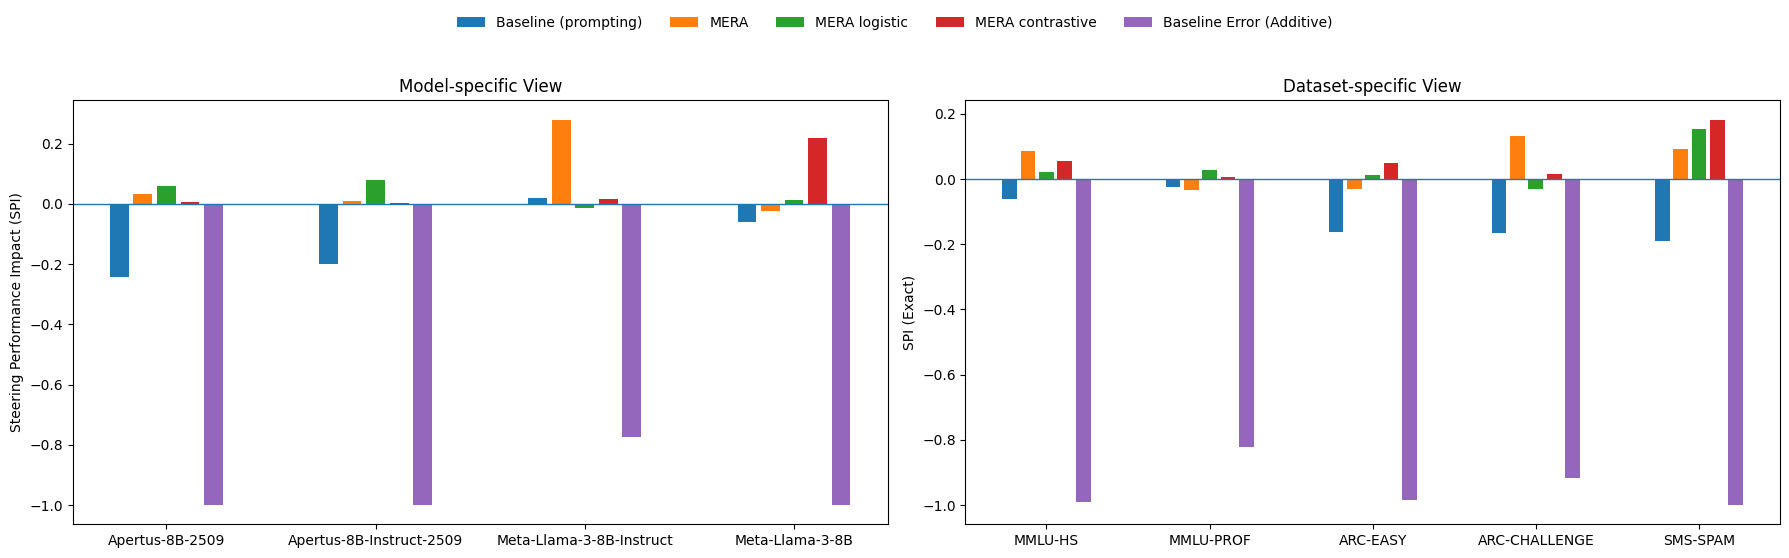

In [ ]:
import os
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths and config
# -----------------------------

ROOT = Path("/iopsstor/scratch/cscs/tunguyen1/mera-runs/steering_outputs")

DATASETS = {
    "MMLU-HS"      : "mmlu_high_school",
    "MMLU-PROF"    : "mmlu_professional",
    "ARC-EASY"     : "ARC-Easy",
    "ARC-CHALLENGE": "ARC-Challenge",
    "SMS-SPAM"     : "sms_spam",
}

MODELS = {
    "Apertus-8B-2509"          : "Apertus-8B-2509",
    "Apertus-8B-Instruct-2509" : "Apertus-8B-Instruct-2509",
    "Meta-Llama-3-8B-Instruct" : "Meta-Llama-3-8B-Instruct",
    "Meta-Llama-3-8B"          : "Meta-Llama-3-8B",
}

# METHODS: for MERA we give a priority list of prefixes
METHODS = {
    "Baseline (prompting)" : ["prompt_steering"],
    "MERA"            : ["optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both"],
    "MERA logistic"   : ["optimal_logistic_probe_1.0_all_layers_all_token_pos_derive_all_with_both"],
    "MERA contrastive": ["optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both"],
    "Baseline Error (Additive)"        : ["additive_probe_1.0_all_layers_all_token_pos"],
}

CALIB_TARGET = "exact"   # for optimal_* methods
N_TEST       = 250


# -----------------------------
# Helpers
# -----------------------------

def load_steering_results(dataset_folder: str, model_folder: str) -> pd.DataFrame:
    """Load and concat all *_steering_all_results.pkl for a (dataset, model)."""
    steering_dir = ROOT / dataset_folder / model_folder / "steering"
    if not steering_dir.exists():
        print(f"[WARN] Missing steering dir: {steering_dir}")
        return pd.DataFrame()

    pkl_paths = sorted(steering_dir.glob("*_steering_all_results.pkl"))
    if not pkl_paths:
        print(f"[WARN] No steering PKLs found in {steering_dir}")
        return pd.DataFrame()

    dfs = []
    for p in pkl_paths:
        with open(p, "rb") as f:
            obj = pickle.load(f)
        df = pd.DataFrame(obj)
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    # de-duplicate just in case
    needed = {"steering_key", "dataset_name", "alpha_calibration_token_pos_target"}
    if needed <= set(df.columns):
        df = df.drop_duplicates(
            subset=list(needed),
            keep="last",
        )

    return df


def pick_row_single(df: pd.DataFrame, key_prefix: str, calib: str | None):
    """Pick row whose steering_key starts with key_prefix (or equals for no_steering)."""
    if key_prefix == "no_steering":
        mask = df["steering_key"].eq("no_steering")
    else:
        mask = df["steering_key"].astype(str).str.startswith(key_prefix)
        if calib is not None and "alpha_calibration_token_pos_target" in df.columns:
            mask &= df["alpha_calibration_token_pos_target"].fillna("").eq(calib)

    sel = df[mask]
    if sel.empty:
        raise ValueError("no match")
    if len(sel) > 1:
        # just take the first, but warn
        print(f"[INFO] Multiple rows for {key_prefix}, taking first.")
    return sel.iloc[0]


def pick_row_multi(df: pd.DataFrame, key_prefixes: list[str]) -> pd.Series:
    """
    Try several prefixes in order (for MERA). For optimal_* we use CALIB_TARGET.
    Returns the first successful row.
    """
    last_err = None
    for prefix in key_prefixes:
        try:
            calib = CALIB_TARGET if prefix.startswith("optimal_") else None
            return pick_row_single(df, prefix, calib)
        except Exception as e:
            last_err = e
            continue
    raise last_err or ValueError("no match in any prefix")


# -----------------------------
# Collect SPI + percentile data
# -----------------------------

records = []

for ds_label, ds_folder in DATASETS.items():
    for model_label, model_folder in MODELS.items():
        df = load_steering_results(ds_folder, model_folder)
        if df.empty:
            continue

        # optional: keep only rows with expected nr_test_samples
        if "nr_test_samples" in df.columns:
            df = df[df["nr_test_samples"] == N_TEST]

        for method_label, prefixes in METHODS.items():
            try:
                row = pick_row_multi(df, prefixes)
            except Exception:
                print(f"[WARN] Missing {method_label} for {ds_label} / {model_label} – skipping.")
                continue

            spi = row.get("SPI Exact", np.nan)
            if prefixes == ["no_steering"] and (pd.isna(spi) or spi == ""):
                spi = 0.0

            rec = {
                "Dataset" : ds_label,
                "Model"   : model_label,
                "Method"  : method_label,
                "SPI Exact" : float(spi),
                # error percentiles (may be NaN if not present)
                "Err25" : row.get("Error Exact 25th Percentile", np.nan),
                "Err75" : row.get("Error Exact 75th Percentile", np.nan),
                "Err90" : row.get("Error Exact 90th Percentile", np.nan),
                "Err95" : row.get("Error Exact 95th Percentile", np.nan),
            }
            records.append(rec)

res = pd.DataFrame(records)
print(res.head())
print("Shape:", res.shape)


# -----------------------------
# Plot (MERA-style)
# -----------------------------

methods_order  = list(METHODS.keys())
models_order   = list(MODELS.keys())
datasets_order = list(DATASETS.keys())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ---------- (1) Model-specific view ----------
ax0 = axes[0]
grouped_model = (
    res.groupby(["Model", "Method"])["SPI Exact"]
       .mean()
       .unstack("Method")
       .reindex(models_order)
)

x = np.arange(len(models_order))
width = 0.09
k = len(methods_order)

# centers go from -(k-1)/2 * width  ...  +(k-1)/2 * width
offsets = (np.arange(k) - (k - 1) / 2) * width

for i, method in enumerate(methods_order):
    if method not in grouped_model.columns:
        continue
    vals = grouped_model[method].values
    ax0.bar(x + offsets[i], vals, width=width, label=method)

ax0.axhline(0, linewidth=1)
ax0.set_xticks(x)
ax0.set_xticklabels(models_order, ha="center")
ax0.set_ylabel("Steering Performance Impact (SPI)")
ax0.set_title("Model-specific View")

# ---------- (2) Dataset-specific view ----------
ax1 = axes[1]
grouped_ds = (
    res.groupby(["Dataset", "Method"])["SPI Exact"]
       .mean()
       .unstack("Method")
       .reindex(datasets_order)
)

x = np.arange(len(datasets_order))
for i, method in enumerate(methods_order):
    if method not in grouped_ds.columns:
        continue
    vals = grouped_ds[method].values
    ax1.bar(x + offsets[i], vals, width=width, label=method)

ax1.axhline(0, linewidth=1)
ax1.set_xticks(x)
ax1.set_xticklabels(datasets_order, ha="center")
ax1.set_ylabel("SPI (Exact)")
ax1.set_title("Dataset-specific View")

# ---------- (3) Aggregated Error Percentiles ----------
# ax2 = axes[2]
# percentiles = [25, 75, 90, 95]

# for method in methods_order:
#     sub = res[res["Method"] == method]
#     if sub.empty:
#         continue
#     y = [
#         sub["Err25"].mean(skipna=True),
#         sub["Err75"].mean(skipna=True),
#         sub["Err90"].mean(skipna=True),
#         sub["Err95"].mean(skipna=True),
#     ]
#     ax2.plot(percentiles, y, marker="o", label=method)

# ax2.set_xlabel("Percentile")
# ax2.set_ylabel("Error")
# ax2.set_title("Aggregated Error Percentiles")
# ax2.set_xticks(percentiles)

ax0.legend().remove()
ax1.legend().remove()
# ax2.legend().remove()

# ---------- Legend & layout ----------
handles_labels = ax0.get_legend_handles_labels()  # get only once
fig.legend(
    handles_labels[0],
    handles_labels[1],
    loc="upper center",
    ncol=len(methods_order),
    bbox_to_anchor=(0.5, 1.12),
    fontsize=10,
    frameon=False,
)

plt.tight_layout()
plt.show()


In [18]:
import os
import pickle
from pathlib import Path

SAVE_DIR = "/iopsstor/scratch/cscs/tunguyen1/mera-runs/steering_outputs"

def get_available_steering_keys(model_name: str, dataset_name: str):
    """
    Return all steering_key values available for a given model+dataset.
    The function looks for *_steering_all_results.pkl inside:
       SAVE_DIR/<dataset>/<model>/steering/
    """

    steering_dir = Path(SAVE_DIR) / dataset_name / model_name / "steering"

    if not steering_dir.exists():
        print(f"[WARN] Directory does not exist: {steering_dir}")
        return []

    # collect all *_steering_all_results.pkl
    pkl_files = list(steering_dir.glob("*_steering_all_results.pkl"))
    if not pkl_files:
        print(f"[WARN] No *_steering_all_results.pkl found in {steering_dir}")
        return []

    steering_keys = set()

    for pkl in pkl_files:
        try:
            with open(pkl, "rb") as f:
                data = pickle.load(f)

            # file may contain a dict or a list of dicts
            if isinstance(data, dict):
                if "steering_key" in data:
                    steering_keys.add(data["steering_key"])

            elif isinstance(data, list):
                for row in data:
                    if isinstance(row, dict) and "steering_key" in row:
                        steering_keys.add(row["steering_key"])
            else:
                print(f"[WARN] Unknown structure in {pkl}")

        except Exception as e:
            print(f"[ERROR] Could not read {pkl}: {e}")

    steering_keys = sorted(list(steering_keys))
    
    print(f"[INFO] Found {len(steering_keys)} steering keys for {dataset_name} / {model_name}")
    return steering_keys


MODELS = [
    "Apertus-8B-2509",
    "Apertus-8B-Instruct-2509",
    "Meta-Llama-3-8B-Instruct",
    "Meta-Llama-3-8B",
]

DATASETS = [
    "mmlu_high_school",
    "mmlu_professional",
    "ARC-Easy",
    "ARC-Challenge",
    "sms_spam"
]

all_results = {}

for ds in DATASETS:
    for model in MODELS:
        print("\n" + "="*80)
        print(f"Checking steering keys for Dataset = {ds} | Model = {model}")
        print("="*80)

        keys = get_available_steering_keys(model, ds)

        if len(keys) == 0:
            print(f"[INFO] No steering keys found for {ds} / {model}")
        else:
            print(f"[INFO] {len(keys)} steering keys found:")
            for k in keys:
                print("   -", k)

        # store results
        all_results[(ds, model)] = keys


Checking steering keys for Dataset = mmlu_high_school | Model = Apertus-8B-2509
[INFO] Found 13 steering keys for mmlu_high_school / Apertus-8B-2509
[INFO] 13 steering keys found:
   - additive_logistic_probe_1.0_all_layers_all_token_pos
   - additive_probe_1.0_all_layers_all_token_pos
   - no_steering
   - optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_exact
   - optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_last
   - optimal_logistic_probe_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_exact
   - optimal_logistic_probe_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_last
   - optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_exact
   - optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both_calibrated_for_last
   - prompt_steering
   - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
   - vanilla_contrastive_1.0_k_200_sets_al

[INFO] Using mmlu_hs_steer_from_mmlu_pro_250_steering_all_results.csv for MMLU-HS <- MMLU-PROF (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_easy_250_steering_all_results.csv for MMLU-HS <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-HS <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_sms_spam_250_steering_all_results.csv for MMLU-HS <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_mmlu_hs_250_steering_all_results.csv for MMLU-PROF <- MMLU-HS (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_easy_250_steering_all_results.csv for MMLU-PROF <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-PROF <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_sms_spam_250_steering_all_results.csv for MMLU-PROF <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using arc_easy_steer_from_mmlu_hs_250_steering_all_results.csv for

,Model,Source,Target,SPI Exact
0,Apertus-8B-2509,MMLU-PROF,MMLU-HS,0.066327
1,Apertus-8B-2509,ARC-EASY,MMLU-HS,-0.092593
2,Apertus-8B-2509,ARC-CHALLENGE,MMLU-HS,-0.037037
3,Apertus-8B-2509,SMS-SPAM,MMLU-HS,-0.018519
4,Apertus-8B-2509,MMLU-HS,MMLU-PROF,0.039801


/tmp/ipykernel_249279/3358207881.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


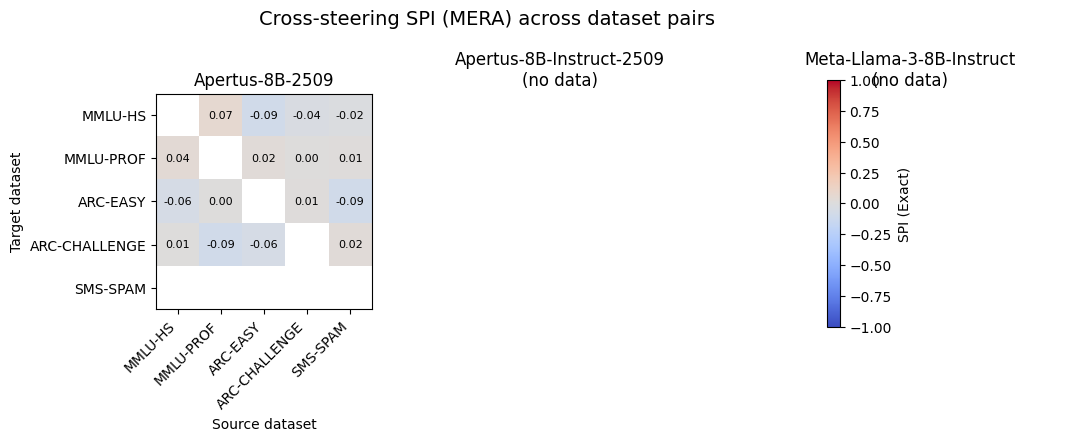

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. CONFIG
# ------------------------------------------------------------------

ROOT = Path("/iopsstor/scratch/cscs/tunguyen1/mera-runs/steering_outputs")

# folder_name on disk
DATASET_FOLDERS = {
    "MMLU-HS"      : "mmlu_high_school",
    "MMLU-PROF"    : "mmlu_professional",
    "ARC-EASY"     : "ARC-Easy",
    "ARC-CHALLENGE": "ARC-Challenge",
    "SMS-SPAM"     : "sms_spam",
}

# short tokens used in filenames (xx_steer_from_yy_*)
DATASET_SHORT = {
    "MMLU-HS"      : "mmlu_hs",
    "MMLU-PROF"    : "mmlu_pro",
    "ARC-EASY"     : "arc_easy",
    "ARC-CHALLENGE": "arc_challenge",
    "SMS-SPAM"     : "sms_spam",
}

# model folder names on disk
MODELS = {
    "Apertus-8B-2509"          : "Apertus-8B-2509",
}

CALIB_TARGET = "exact"   # use SPI Exact

# ------------------------------------------------------------------
# 2. HELPERS
# ------------------------------------------------------------------

def load_cross_csv(target_ds_label: str, source_ds_label: str, model_folder: str) -> pd.DataFrame:
    """Load the *_steer_from_* CSV for a given (source,target,model)."""
    tgt_folder = DATASET_FOLDERS[target_ds_label]
    tgt_short  = DATASET_SHORT[target_ds_label]
    src_short  = DATASET_SHORT[source_ds_label]

    steering_dir = ROOT / tgt_folder / model_folder / "steering"
    if not steering_dir.is_dir():
        print(f"[WARN] steering dir missing: {steering_dir}")
        return pd.DataFrame()

    pattern = f"{tgt_short}_steer_from_{src_short}_*_steering_all_results.csv"
    matches = sorted(steering_dir.glob(pattern))
    if not matches:
        print(f"[WARN] No cross CSV for {target_ds_label} <- {source_ds_label} ({model_folder})")
        return pd.DataFrame()

    csv_path = matches[-1]
    print(f"[INFO] Using {csv_path.name} for {target_ds_label} <- {source_ds_label} ({model_folder})")
    return pd.read_csv(csv_path)


def pick_mera_row(df: pd.DataFrame) -> pd.Series | None:
    """
    Pick MERA row: prefer optimal_probe..., otherwise fall back to optimal_logistic_probe...
    Always require calibration target == 'exact'.
    """
    if df.empty:
        return None

    # Ensure column exists
    if "steering_key" not in df.columns:
        print("[WARN] No steering_key column in df")
        return None

    mask_exact = df["alpha_calibration_token_pos_target"].fillna("").eq(CALIB_TARGET)

    # 1) try optimal_probe
    m1 = mask_exact & df["steering_key"].str.contains(
        "optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both", na=False
    )
    sel = df[m1]
    if sel.empty:
        # 2) fall back to optimal_logistic_probe
        m2 = mask_exact & df["steering_key"].str.contains(
            "optimal_logistic_probe_1.0_all_layers_all_token_pos_derive_all_with_both", na=False
        )
        sel = df[m2]

    if sel.empty:
        return None
    if len(sel) > 1:
        sel = sel.iloc[[0]]
    return sel.iloc[0]


# ------------------------------------------------------------------
# 3. COLLECT SPI FOR ALL (SOURCE, TARGET) PAIRS
# ------------------------------------------------------------------

records = []

for model_label, model_folder in MODELS.items():
    for target_label in DATASET_FOLDERS.keys():
        for source_label in DATASET_FOLDERS.keys():
            if source_label == target_label:
                continue  # skip same-dataset steering

            df = load_cross_csv(target_label, source_label, model_folder)
            if df.empty:
                continue

            mera_row = pick_mera_row(df)
            if mera_row is None:
                print(f"[WARN] No MERA row for {target_label} <- {source_label} ({model_label})")
                continue

            records.append(
                {
                    "Model"   : model_label,
                    "Source"  : source_label,
                    "Target"  : target_label,
                    "SPI Exact": mera_row["SPI Exact"],
                }
            )

cross_spi = pd.DataFrame(records)
print("\nCollected cross-steering SPI rows:")
display(cross_spi.head())


# ------------------------------------------------------------------
# 4. PLOT HEATMAPS (ONE PER MODEL)
# ------------------------------------------------------------------

datasets_order = list(DATASET_FOLDERS.keys())

n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4), sharey=True)

if n_models == 1:
    axes = [axes]

for ax, (model_label, _) in zip(axes, MODELS.items()):
    sub = cross_spi[cross_spi["Model"] == model_label]
    if sub.empty:
        ax.set_title(f"{model_label}\n(no data)")
        ax.axis("off")
        continue

    # pivot to Target x Source matrix
    mat = sub.pivot(index="Target", columns="Source", values="SPI Exact")
    mat = mat.reindex(index=datasets_order, columns=datasets_order)
    # zero on diagonal (self-steering not defined)
    for ds in datasets_order:
        if ds in mat.index and ds in mat.columns:
            mat.loc[ds, ds] = np.nan

    im = ax.imshow(mat.values, cmap="coolwarm", vmin=-1.0, vmax=1.0)

    ax.set_xticks(range(len(datasets_order)))
    ax.set_xticklabels(datasets_order, rotation=45, ha="right")
    ax.set_yticks(range(len(datasets_order)))
    ax.set_yticklabels(datasets_order)
    ax.set_title(model_label)
    ax.set_xlabel("Source dataset")
    ax.set_ylabel("Target dataset")

    # write values in cells
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center", fontsize=8, color="black"
                )

# one shared colorbar
fig.colorbar(im, ax=axes, shrink=0.8, label="SPI (Exact)")
fig.suptitle("Cross-steering SPI (MERA) across dataset pairs", fontsize=14)
plt.tight_layout()
plt.show()


================ No steering ================
[INFO] Using mmlu_hs_steer_from_mmlu_pro_250_steering_all_results.csv for MMLU-HS <- MMLU-PROF (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_easy_250_steering_all_results.csv for MMLU-HS <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-HS <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_sms_spam_250_steering_all_results.csv for MMLU-HS <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_mmlu_hs_250_steering_all_results.csv for MMLU-PROF <- MMLU-HS (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_easy_250_steering_all_results.csv for MMLU-PROF <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-PROF <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_sms_spam_250_steering_all_results.csv for MMLU-PROF <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using arc_easy_stee

,Model,Source,Target,SPI Exact
0,Apertus-8B-2509,MMLU-PROF,MMLU-HS,NaN
1,Apertus-8B-2509,ARC-EASY,MMLU-HS,NaN
2,Apertus-8B-2509,ARC-CHALLENGE,MMLU-HS,NaN
3,Apertus-8B-2509,SMS-SPAM,MMLU-HS,NaN
4,Apertus-8B-2509,MMLU-HS,MMLU-PROF,NaN


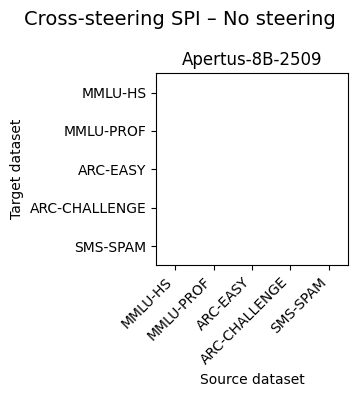


================ Prompt steering ================
[INFO] Using mmlu_hs_steer_from_mmlu_pro_250_steering_all_results.csv for MMLU-HS <- MMLU-PROF (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_easy_250_steering_all_results.csv for MMLU-HS <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-HS <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_sms_spam_250_steering_all_results.csv for MMLU-HS <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_mmlu_hs_250_steering_all_results.csv for MMLU-PROF <- MMLU-HS (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_easy_250_steering_all_results.csv for MMLU-PROF <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-PROF <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_sms_spam_250_steering_all_results.csv for MMLU-PROF <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using arc_easy_

,Model,Source,Target,SPI Exact
0,Apertus-8B-2509,MMLU-PROF,MMLU-HS,-0.370370
1,Apertus-8B-2509,ARC-EASY,MMLU-HS,-0.370370
2,Apertus-8B-2509,ARC-CHALLENGE,MMLU-HS,-0.370370
3,Apertus-8B-2509,SMS-SPAM,MMLU-HS,-0.370370
4,Apertus-8B-2509,MMLU-HS,MMLU-PROF,-0.061224


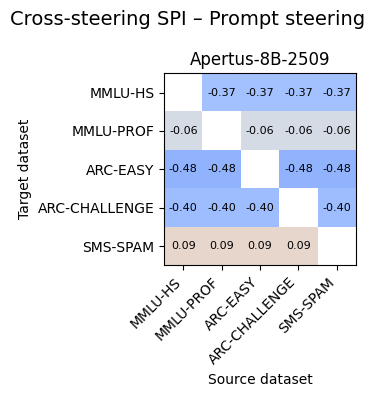


================ Optimal probe ================
[INFO] Using mmlu_hs_steer_from_mmlu_pro_250_steering_all_results.csv for MMLU-HS <- MMLU-PROF (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_easy_250_steering_all_results.csv for MMLU-HS <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-HS <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_sms_spam_250_steering_all_results.csv for MMLU-HS <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_mmlu_hs_250_steering_all_results.csv for MMLU-PROF <- MMLU-HS (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_easy_250_steering_all_results.csv for MMLU-PROF <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-PROF <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_sms_spam_250_steering_all_results.csv for MMLU-PROF <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using arc_easy_st

,Model,Source,Target,SPI Exact
0,Apertus-8B-2509,MMLU-PROF,MMLU-HS,0.066327
1,Apertus-8B-2509,ARC-EASY,MMLU-HS,-0.092593
2,Apertus-8B-2509,ARC-CHALLENGE,MMLU-HS,-0.037037
3,Apertus-8B-2509,SMS-SPAM,MMLU-HS,-0.018519
4,Apertus-8B-2509,MMLU-HS,MMLU-PROF,0.039801


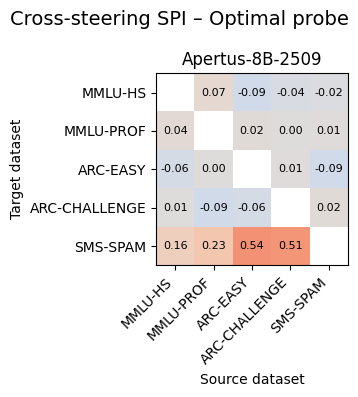


================ Optimal logistic ================
[INFO] Using mmlu_hs_steer_from_mmlu_pro_250_steering_all_results.csv for MMLU-HS <- MMLU-PROF (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_easy_250_steering_all_results.csv for MMLU-HS <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-HS <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_sms_spam_250_steering_all_results.csv for MMLU-HS <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_mmlu_hs_250_steering_all_results.csv for MMLU-PROF <- MMLU-HS (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_easy_250_steering_all_results.csv for MMLU-PROF <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-PROF <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_sms_spam_250_steering_all_results.csv for MMLU-PROF <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using arc_easy

,Model,Source,Target,SPI Exact
0,Apertus-8B-2509,MMLU-PROF,MMLU-HS,-0.018519
1,Apertus-8B-2509,ARC-EASY,MMLU-HS,-0.018519
2,Apertus-8B-2509,ARC-CHALLENGE,MMLU-HS,0.005102
3,Apertus-8B-2509,SMS-SPAM,MMLU-HS,0.030612
4,Apertus-8B-2509,MMLU-HS,MMLU-PROF,0.014925


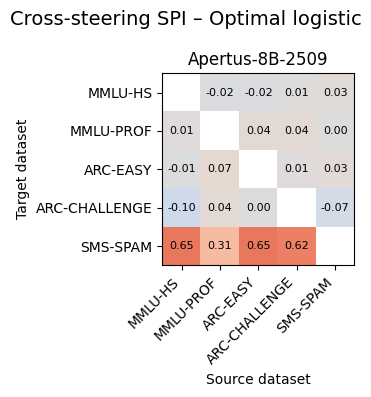


================ Additive ================
[INFO] Using mmlu_hs_steer_from_mmlu_pro_250_steering_all_results.csv for MMLU-HS <- MMLU-PROF (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_easy_250_steering_all_results.csv for MMLU-HS <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-HS <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_hs_steer_from_sms_spam_250_steering_all_results.csv for MMLU-HS <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_mmlu_hs_250_steering_all_results.csv for MMLU-PROF <- MMLU-HS (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_easy_250_steering_all_results.csv for MMLU-PROF <- ARC-EASY (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_arc_challenge_250_steering_all_results.csv for MMLU-PROF <- ARC-CHALLENGE (Apertus-8B-2509)
[INFO] Using mmlu_pro_steer_from_sms_spam_250_steering_all_results.csv for MMLU-PROF <- SMS-SPAM (Apertus-8B-2509)
[INFO] Using arc_easy_steer_f

,Model,Source,Target,SPI Exact
0,Apertus-8B-2509,MMLU-PROF,MMLU-HS,-1.0
1,Apertus-8B-2509,ARC-EASY,MMLU-HS,-1.0
2,Apertus-8B-2509,ARC-CHALLENGE,MMLU-HS,-1.0
3,Apertus-8B-2509,SMS-SPAM,MMLU-HS,-1.0
4,Apertus-8B-2509,MMLU-HS,MMLU-PROF,-1.0


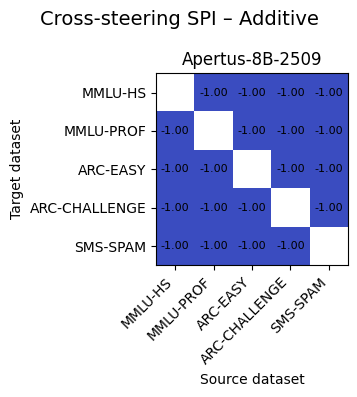

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. CONFIG
# ------------------------------------------------------------------

ROOT = Path("/iopsstor/scratch/cscs/tunguyen1/mera-runs/steering_outputs")

DATASET_FOLDERS = {
    "MMLU-HS"      : "mmlu_high_school",
    "MMLU-PROF"    : "mmlu_professional",
    "ARC-EASY"     : "ARC-Easy",
    "ARC-CHALLENGE": "ARC-Challenge",
    "SMS-SPAM"     : "sms_spam",
}

# short tokens used in filenames: {tgt_short}_steer_from_{src_short}_...
DATASET_SHORT = {
    "MMLU-HS"      : "mmlu_hs",
    "MMLU-PROF"    : "mmlu_pro",
    "ARC-EASY"     : "arc_easy",
    "ARC-CHALLENGE": "arc_challenge",
    "SMS-SPAM"     : "sms_spam",
}

MODELS = {
    "Apertus-8B-2509"          : "Apertus-8B-2509",
}

# pretty label -> internal key
METHODS = {
    "No steering"          : "no_steering",
    "Prompt steering"      : "prompt_steering",
    "Optimal probe"        : "optimal_probe",
    "Optimal logistic"     : "optimal_logistic_probe",
    "Additive"             : "additive_probe",
}

CALIB_TARGET = "exact"   # we look at SPI Exact

datasets_order = list(DATASET_FOLDERS.keys())

# ------------------------------------------------------------------
# 2. HELPERS
# ------------------------------------------------------------------

def read_csv_safe(path: Path) -> pd.DataFrame:
    """Robust CSV reader (handles weird list columns by using python engine)."""
    return pd.read_csv(path, engine="python")

def load_cross_csv(target_ds_label: str, source_ds_label: str, model_folder: str) -> pd.DataFrame:
    """
    Load the combined CSV: {tgt_short}_steer_from_{src_short}_*_steering_all_results.csv
    Returns an empty DataFrame if not found.
    """
    tgt_folder = DATASET_FOLDERS[target_ds_label]
    tgt_short  = DATASET_SHORT[target_ds_label]
    src_short  = DATASET_SHORT[source_ds_label]

    steering_dir = ROOT / tgt_folder / model_folder / "steering"
    if not steering_dir.is_dir():
        print(f"[WARN] steering dir missing: {steering_dir}")
        return pd.DataFrame()

    pattern = f"{tgt_short}_steer_from_{src_short}_*_steering_all_results.csv"
    matches = sorted(steering_dir.glob(pattern))
    if not matches:
        print(f"[WARN] No cross CSV for {target_ds_label} <- {source_ds_label} ({model_folder})")
        return pd.DataFrame()

    csv_path = matches[-1]
    print(f"[INFO] Using {csv_path.name} for {target_ds_label} <- {source_ds_label} ({model_folder})")
    return read_csv_safe(csv_path)


def pick_row_for_method(df: pd.DataFrame, method_key: str) -> pd.Series | None:
    """
    Pick the appropriate row from df for a given steering method.
    We match on `steering_key` patterns and sometimes on calibration target.
    """
    if df.empty or "steering_key" not in df.columns:
        return None

    sk = df["steering_key"].astype(str)
    calib = df["alpha_calibration_token_pos_target"].fillna("")

    if method_key == "no_steering":
        mask = sk.eq("no_steering")

    elif method_key == "prompt_steering":
        mask = sk.str.startswith("prompt_steering")

    elif method_key == "optimal_probe":
        mask = (
            calib.eq(CALIB_TARGET)
            & sk.str.contains("optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both", na=False)
        )

    elif method_key == "optimal_logistic_probe":
        mask = (
            calib.eq(CALIB_TARGET)
            & sk.str.contains("optimal_logistic_probe_1.0_all_layers_all_token_pos_derive_all_with_both", na=False)
        )

    elif method_key == "additive_probe":
        # additive has no calibration target
        mask = sk.str.contains("additive_probe_1.0_all_layers_all_token_pos", na=False)

    else:
        return None

    sel = df[mask]
    if sel.empty:
        return None
    if len(sel) > 1:
        sel = sel.iloc[[0]]
    return sel.iloc[0]


def plot_cross_spi_for_method(method_label: str, method_key: str):
    """
    Collect cross-steering SPI for a single steering method across all
    (source, target, model) and plot heatmaps (one per model).
    """
    records = []

    for model_label, model_folder in MODELS.items():
        for target_label in DATASET_FOLDERS.keys():
            for source_label in DATASET_FOLDERS.keys():
                if source_label == target_label:
                    continue  # skip self

                df = load_cross_csv(target_label, source_label, model_folder)
                if df.empty:
                    continue

                row = pick_row_for_method(df, method_key)
                if row is None:
                    print(f"[WARN] No row for {method_key} in {target_label} <- {source_label} ({model_label})")
                    continue

                records.append(
                    {
                        "Model"    : model_label,
                        "Source"   : source_label,
                        "Target"   : target_label,
                        "SPI Exact": row["SPI Exact"],
                    }
                )

    cross_spi = pd.DataFrame(records)
    print(f"\n[INFO] {method_label}: cross_spi shape = {cross_spi.shape}")
    display(cross_spi.head())

    if cross_spi.empty:
        print(f"[ERROR] No data for method '{method_label}'. Skipping plot.\n")
        return

    # ---------- Plot ----------
    n_models = len(MODELS)
    fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4), sharey=True)

    if n_models == 1:
        axes = [axes]

    for ax, (model_label, _) in zip(axes, MODELS.items()):
        sub = cross_spi[cross_spi["Model"] == model_label]
        if sub.empty:
            ax.set_title(f"{model_label}\n(no data)")
            ax.axis("off")
            continue

        mat = sub.pivot(index="Target", columns="Source", values="SPI Exact")
        mat = mat.reindex(index=datasets_order, columns=datasets_order)

        # clear diagonal
        for ds in datasets_order:
            if ds in mat.index and ds in mat.columns:
                mat.loc[ds, ds] = np.nan

        im = ax.imshow(mat.values, cmap="coolwarm", vmin=-1.0, vmax=1.0)

        ax.set_xticks(range(len(datasets_order)))
        ax.set_xticklabels(datasets_order, rotation=45, ha="right")
        ax.set_yticks(range(len(datasets_order)))
        ax.set_yticklabels(datasets_order)
        ax.set_title(model_label)
        ax.set_xlabel("Source dataset")
        ax.set_ylabel("Target dataset")

        # numbers inside cells
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat.iloc[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

#     cbar = fig.colorbar(
#     im,
#     ax=axes,
#     shrink=0.8,
#     location="right",
#     pad=0.02   # increase to move further away
# )
#     cbar.set_label("SPI (Exact)")
    fig.suptitle(f"Cross-steering SPI – {method_label}", fontsize=14)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# 3. RUN FOR ALL METHODS  (this will produce 5 separate figures)
# ------------------------------------------------------------------

for method_label, method_key in METHODS.items():
    print(f"\n================ {method_label} ================")
    plot_cross_spi_for_method(method_label, method_key)